In [25]:
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import ToPILImage
import torchvision.transforms.v2 as tfs
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

In [26]:
# Скрипт для загрузки датасета

transform = tfs.ToPILImage()

mnist_train = datasets.MNIST(root='./mnist_data', download=True, train=True)
mnist_test = datasets.MNIST(root='./mnist_data', download=True, train=False)

dir_out = 'dataset'
file_format = 'format.json'
train_data = {'dir': "train", 'data': mnist_train}
test_data = {'dir': "test", 'data': mnist_test}

if not os.path.exists(dir_out):
    os.mkdir(dir_out)

    for info in (train_data, test_data):
        os.mkdir(os.path.join(dir_out, info['dir']))

        for i in range(10):
            os.mkdir(os.path.join(dir_out, info['dir'], f"class_{i}"))

for info in (train_data, test_data):
    for i in range(10):
        path = os.path.join(dir_out, info['dir'], f"class_{i}")
        cls = info['data'].data[info['data'].targets == i]

        for n, x in enumerate(cls):
            x = transform(x)
            x.save(os.path.join(path, f"img_{n}.png"), "png")

targets = dict()
for i in range(10):
    targets[f'class_{i}'] = i

fp = open(os.path.join(dir_out, file_format), "w")
json.dump(targets, fp)
fp.close()

In [27]:
# Свой класс датасета

class CustomDataset(Dataset):
    def __init__(self, path, train=True, transform=None):
        self.path = os.path.join(path, "train" if train else "test")
        self.transform = transform

        # Раскладываем датасет в стандартную организацию файлов
        with open(os.path.join(path, "format.json"), "r") as fp:
            self.format = json.load(fp)
 
        self.length = 0
        self.files = []
        self.targets = torch.eye(10)
 
        for _dir, _target in self.format.items():
            path = os.path.join(self.path, _dir)
            list_files = os.listdir(path)
            self.length += len(list_files)
            self.files.extend(map(lambda _x: (os.path.join(path, _x), _target), list_files))
    
    # Для получения элемента с индексом item
    def __getitem__(self, item):
        path_file, target = self.files[item]
        t = self.targets[target]
        img = Image.open(path_file)
        # Нормировка [0, 1]
        if self.transform:
            img = self.transform(img).ravel().float()
 
        return img, t
    
    # Размер датасета
    def __len__(self):
        return self.length

In [28]:
# Свой класс нейронной сети

class CustomNN(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=128, output_dim=10):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [29]:
dataset = CustomDataset('dataset', transform=tfs.ToImage()) # Датасет
dataset_test = CustomDataset('dataset', train=False, transform=tfs.ToImage()) # Датасет для тестов
loader = DataLoader(dataset, batch_size=64, shuffle=True) # Даталоадер
loader_test = DataLoader(dataset_test, batch_size=64, shuffle=False) # Даталоадер для тестов


In [30]:
# Тест с кросс-энтропией

model = CustomNN() # Создаем объект нейронной сети
optimizer = optim.Adam(params=model.parameters(), lr=0.001) # Оптимизатор Adam
loss_function = nn.CrossEntropyLoss() # Кросс-энтропия в качестве функции потерь

epochs = 5 # Количество эпох
losses = []
model.train() # Переводим модель в тренировочный режим

CustomNN(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [31]:
# Обучение

for epoch in range(epochs):
    running_loss = 0.0

    pbar = tqdm(loader, desc=f'Epoch {epoch+1}/{epochs}')
    for images, labels_onehot in pbar:
        labels = torch.argmax(labels_onehot, dim=1) # Вытаскиваем метки
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        # Текущее значение функции потери
        running_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(loader)
    losses.append(epoch_loss)
    print(f'Эпоха {epoch+1}, средний значение функции потери в эпохе: {epoch_loss:.4f}')

Epoch 1/5: 100%|██████████| 938/938 [05:55<00:00,  2.64it/s, loss=0.452] 


Эпоха 1, средний значение функции потери в эпохе: 0.5136


Epoch 2/5: 100%|██████████| 938/938 [00:18<00:00, 50.76it/s, loss=0.408]  


Эпоха 2, средний значение функции потери в эпохе: 0.1900


Epoch 3/5: 100%|██████████| 938/938 [00:18<00:00, 50.71it/s, loss=0.154]  


Эпоха 3, средний значение функции потери в эпохе: 0.1599


Epoch 4/5: 100%|██████████| 938/938 [00:18<00:00, 49.82it/s, loss=0.131]  


Эпоха 4, средний значение функции потери в эпохе: 0.1490


Epoch 5/5: 100%|██████████| 938/938 [00:18<00:00, 50.53it/s, loss=0.0131] 

Эпоха 5, средний значение функции потери в эпохе: 0.1457


In [32]:
# Индексы чисел для сравнения
indices = [25, 1094, 2123, 3150, 4185, 5159, 6035, 7014, 8021, 8995]

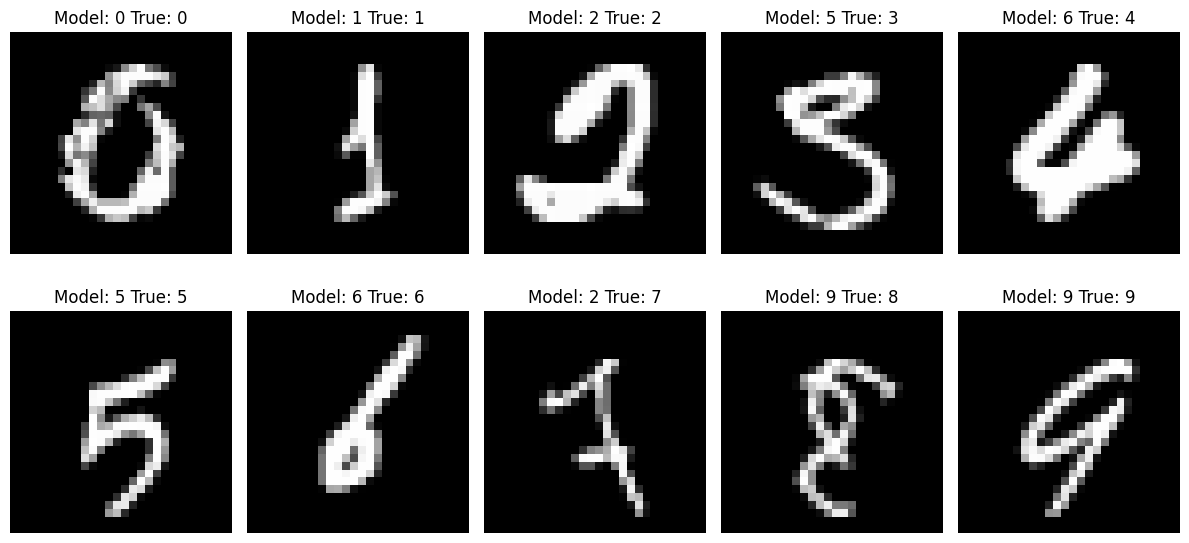

In [33]:
model.eval()
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.flatten()

for i, idx in enumerate(indices):
    img_tensor, label_onehot = dataset_test[idx]
    img_batch = img_tensor.unsqueeze(0)

    with torch.no_grad():
        output = model(img_batch)
        pred = torch.argmax(output, dim=1).item()
    true_label = torch.argmax(label_onehot).item()

    img_2d = img_tensor.view(28, 28)

    axes[i].imshow(img_2d, cmap='gray')
    axes[i].set_title(f'Model: {pred} True: {true_label}')
    axes[i].axis('off')

for j in range(i+1, len(axes)):
    axes[j].axis('off')
    
plt.tight_layout()
plt.show()

In [34]:
# Тест с MSELoss

model = CustomNN() # Создаем объект нейронной сети
optimizer = optim.Adam(params=model.parameters(), lr=0.001) # Оптимизатор Adam
loss_function = nn.MSELoss() # Среднеквадратичная ошибка между предсказанными значениями

epochs = 5 # Количество эпох
losses = []
model.train() # Переводим модель в тренировочный режим

CustomNN(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [35]:
# Обучение

for epoch in range(epochs):
    running_loss = 0.0

    pbar = tqdm(loader, desc=f'Epoch {epoch+1}/{epochs}')
    for images, labels_onehot in pbar:
        optimizer.zero_grad()
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        loss = loss_function(probs, labels_onehot.float())
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(loader)
    losses.append(epoch_loss)
    print(f'Эпоха {epoch+1}, средний значение функции потери: {epoch_loss:.4f}')

Epoch 1/5: 100%|██████████| 938/938 [00:18<00:00, 50.90it/s, loss=0.1]   


Эпоха 1, средний значение функции потери: 0.1129


Epoch 2/5: 100%|██████████| 938/938 [00:17<00:00, 52.82it/s, loss=0.0875]


Эпоха 2, средний значение функции потери: 0.0945


Epoch 3/5: 100%|██████████| 938/938 [00:17<00:00, 54.62it/s, loss=0.119] 


Эпоха 3, средний значение функции потери: 0.0810


Epoch 4/5: 100%|██████████| 938/938 [00:17<00:00, 53.97it/s, loss=0.0687]


Эпоха 4, средний значение функции потери: 0.0768


Epoch 5/5: 100%|██████████| 938/938 [00:19<00:00, 48.70it/s, loss=0.0812]

Эпоха 5, средний значение функции потери: 0.0751


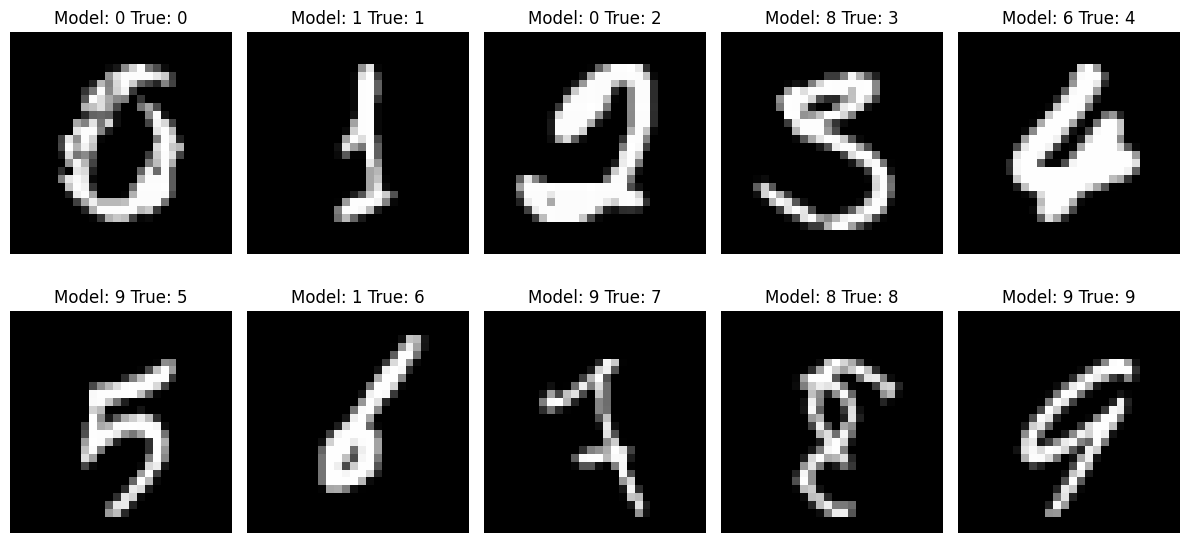

In [36]:
model.eval()
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.flatten()

for i, idx in enumerate(indices):
    img_tensor, label_onehot = dataset_test[idx]
    img_batch = img_tensor.unsqueeze(0)

    with torch.no_grad():
        output = model(img_batch)
        pred = torch.argmax(output, dim=1).item()
    true_label = torch.argmax(label_onehot).item()

    img_2d = img_tensor.view(28, 28)

    axes[i].imshow(img_2d, cmap='gray')
    axes[i].set_title(f'Model: {pred} True: {true_label}')
    axes[i].axis('off')

for j in range(i+1, len(axes)):
    axes[j].axis('off')
    
plt.tight_layout()
plt.show()

In [37]:
# Тест с отрицательным логарифмическим правдоподобием (требует log_softmax, фактически становиться равна cross entropy)

model = CustomNN() # Создаем объект нейронной сети
optimizer = optim.Adam(params=model.parameters(), lr=0.001) # Оптимизатор Adam
loss_function = nn.NLLLoss() # Отрицательное логарифмическое правдоподобие

epochs = 5 # Количество эпох
losses = []
model.train() # Переводим модель в тренировочный режим

CustomNN(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [38]:
# Обучение

for epoch in range(epochs):
    running_loss = 0.0

    pbar = tqdm(loader, desc=f'Epoch {epoch+1}/{epochs}')
    for images, labels_onehot in pbar:
        labels = torch.argmax(labels_onehot, dim=1) # Вытаскиваем метки
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_function(torch.log_softmax(outputs, dim=1), labels)
        loss.backward()
        optimizer.step()
        # Текущее значение функции потери
        running_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(loader)
    losses.append(epoch_loss)
    print(f'Эпоха {epoch+1}, средний значение функции потери в эпохе: {epoch_loss:.4f}')

Epoch 1/5: 100%|██████████| 938/938 [00:19<00:00, 47.63it/s, loss=0.0809]


Эпоха 1, средний значение функции потери в эпохе: 0.5304


Epoch 2/5: 100%|██████████| 938/938 [00:18<00:00, 50.69it/s, loss=0.162]  


Эпоха 2, средний значение функции потери в эпохе: 0.1794


Epoch 3/5: 100%|██████████| 938/938 [00:17<00:00, 53.25it/s, loss=0.115]  


Эпоха 3, средний значение функции потери в эпохе: 0.1607


Epoch 4/5: 100%|██████████| 938/938 [00:18<00:00, 49.50it/s, loss=0.0194] 


Эпоха 4, средний значение функции потери в эпохе: 0.1460


Epoch 5/5: 100%|██████████| 938/938 [00:18<00:00, 49.94it/s, loss=0.0125] 

Эпоха 5, средний значение функции потери в эпохе: 0.1466


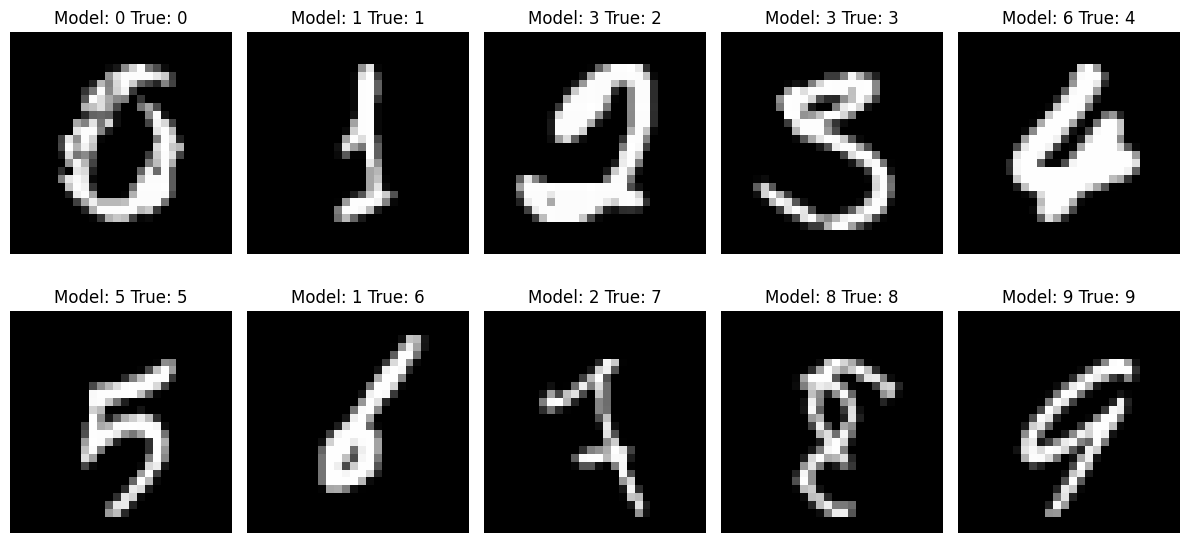

In [39]:
model.eval()
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.flatten()

for i, idx in enumerate(indices):
    img_tensor, label_onehot = dataset_test[idx]
    img_batch = img_tensor.unsqueeze(0)

    with torch.no_grad():
        output = model(img_batch)
        pred = torch.argmax(output, dim=1).item()
    true_label = torch.argmax(label_onehot).item()

    img_2d = img_tensor.view(28, 28)

    axes[i].imshow(img_2d, cmap='gray')
    axes[i].set_title(f'Model: {pred} True: {true_label}')
    axes[i].axis('off')

for j in range(i+1, len(axes)):
    axes[j].axis('off')
    
plt.tight_layout()
plt.show()

In [40]:
# Тест с дивергенцией Кульбака-Лейблера

model = CustomNN() # Создаем объект нейронной сети
optimizer = optim.Adam(params=model.parameters(), lr=0.001) # Оптимизатор Adam
loss_function = nn.KLDivLoss(reduction='batchmean')

epochs = 5 # Количество эпох
losses = []
model.train() # Переводим модель в тренировочный режим

CustomNN(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [41]:
# Обучение

for epoch in range(epochs):
    running_loss = 0.0

    pbar = tqdm(loader, desc=f'Epoch {epoch+1}/{epochs}')
    for images, labels_onehot in pbar:
        labels = torch.argmax(labels_onehot, dim=1) # Вытаскиваем метки
        optimizer.zero_grad()
        outputs = model(images)
        probs = torch.log_softmax(outputs, dim=1)
        loss = loss_function(probs, labels_onehot)
        loss.backward()
        optimizer.step()
        # Текущее значение функции потери
        running_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(loader)
    losses.append(epoch_loss)
    print(f'Эпоха {epoch+1}, средний значение функции потери в эпохе: {epoch_loss:.4f}')

Epoch 1/5: 100%|██████████| 938/938 [00:19<00:00, 49.18it/s, loss=0.168] 


Эпоха 1, средний значение функции потери в эпохе: 0.5968


Epoch 2/5: 100%|██████████| 938/938 [00:18<00:00, 49.63it/s, loss=0.082] 


Эпоха 2, средний значение функции потери в эпохе: 0.1845


Epoch 3/5: 100%|██████████| 938/938 [00:17<00:00, 53.14it/s, loss=0.179]  


Эпоха 3, средний значение функции потери в эпохе: 0.1620


Epoch 4/5: 100%|██████████| 938/938 [00:17<00:00, 52.44it/s, loss=0.0218] 


Эпоха 4, средний значение функции потери в эпохе: 0.1482


Epoch 5/5: 100%|██████████| 938/938 [00:19<00:00, 49.31it/s, loss=0.202]  

Эпоха 5, средний значение функции потери в эпохе: 0.1500


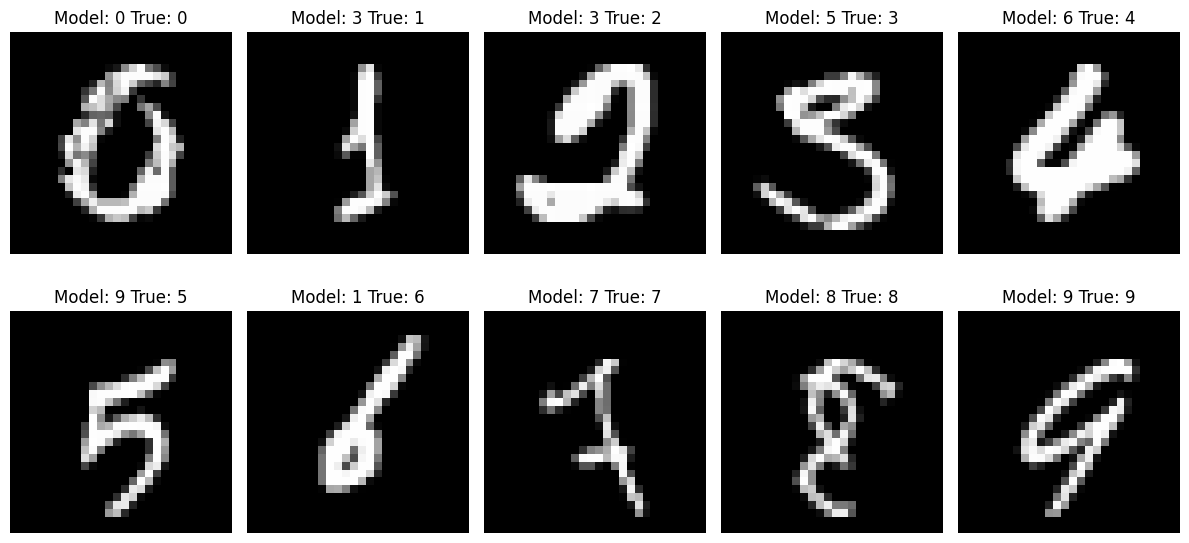

In [42]:
model.eval()
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.flatten()

for i, idx in enumerate(indices):
    img_tensor, label_onehot = dataset_test[idx]
    img_batch = img_tensor.unsqueeze(0)

    with torch.no_grad():
        output = model(img_batch)
        pred = torch.argmax(output, dim=1).item()
    true_label = torch.argmax(label_onehot).item()

    img_2d = img_tensor.view(28, 28)

    axes[i].imshow(img_2d, cmap='gray')
    axes[i].set_title(f'Model: {pred} True: {true_label}')
    axes[i].axis('off')

for j in range(i+1, len(axes)):
    axes[j].axis('off')
    
plt.tight_layout()
plt.show()

In [43]:
# Тест с MultiMarginLoss

model = CustomNN() # Создаем объект нейронной сети
optimizer = optim.Adam(params=model.parameters(), lr=0.001) # Оптимизатор Adam
loss_function = nn.MultiMarginLoss(margin=1.0)

epochs = 5 # Количество эпох
losses = []
model.train() # Переводим модель в тренировочный режим

CustomNN(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [44]:
# Обучение

for epoch in range(epochs):
    running_loss = 0.0

    pbar = tqdm(loader, desc=f'Epoch {epoch+1}/{epochs}')
    for images, labels_onehot in pbar:
        labels = torch.argmax(labels_onehot, dim=1) # Вытаскиваем метки
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        # Текущее значение функции потери
        running_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(loader)
    losses.append(epoch_loss)
    print(f'Эпоха {epoch+1}, средний значение функции потери в эпохе: {epoch_loss:.4f}')

Epoch 1/5: 100%|██████████| 938/938 [00:18<00:00, 49.84it/s, loss=0.0252] 


Эпоха 1, средний значение функции потери в эпохе: 0.1361


Epoch 2/5: 100%|██████████| 938/938 [00:18<00:00, 51.74it/s, loss=0.0471]  


Эпоха 2, средний значение функции потери в эпохе: 0.0332


Epoch 3/5: 100%|██████████| 938/938 [00:18<00:00, 51.74it/s, loss=0.025]   


Эпоха 3, средний значение функции потери в эпохе: 0.0278


Epoch 4/5: 100%|██████████| 938/938 [00:18<00:00, 50.19it/s, loss=0.0134]  


Эпоха 4, средний значение функции потери в эпохе: 0.0270


Epoch 5/5: 100%|██████████| 938/938 [00:18<00:00, 50.27it/s, loss=0.00524] 

Эпоха 5, средний значение функции потери в эпохе: 0.0291


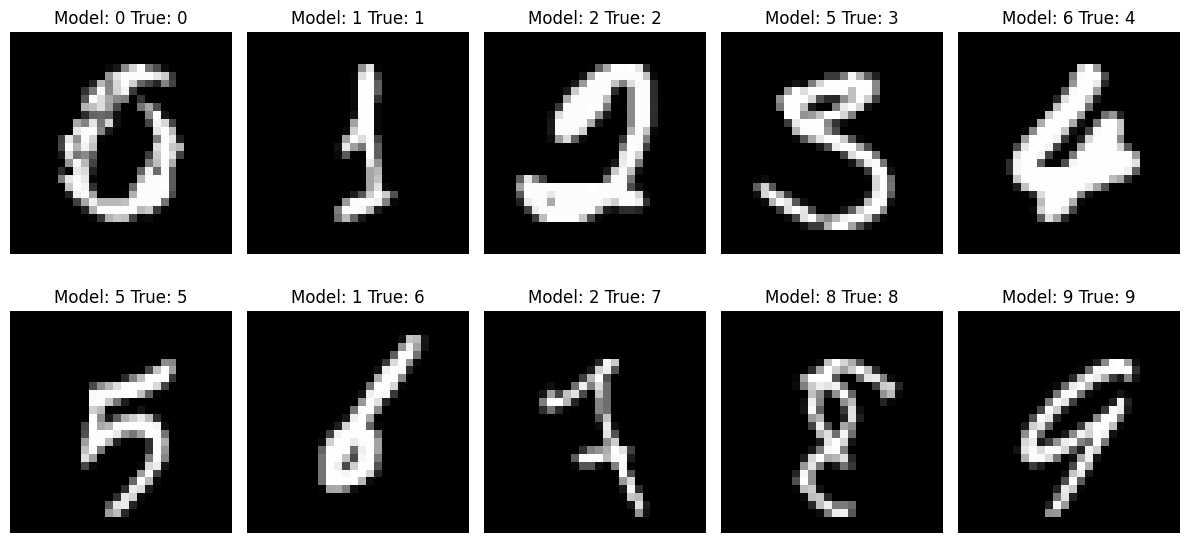

In [45]:
model.eval()
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.flatten()

for i, idx in enumerate(indices):
    img_tensor, label_onehot = dataset_test[idx]
    img_batch = img_tensor.unsqueeze(0)

    with torch.no_grad():
        output = model(img_batch)
        pred = torch.argmax(output, dim=1).item()
    true_label = torch.argmax(label_onehot).item()

    img_2d = img_tensor.view(28, 28)

    axes[i].imshow(img_2d, cmap='gray')
    axes[i].set_title(f'Model: {pred} True: {true_label}')
    axes[i].axis('off')

for j in range(i+1, len(axes)):
    axes[j].axis('off')
    
plt.tight_layout()
plt.show()